# Lab Problem Statement 6: Customer Segmentation and Predictive Analytics Using Machine Learning (R)

**Course:** R Programming Laboratory
**Platform:** Google Colab with the **R runtime**

**Before running:** go to `Runtime > Change runtime type` and select **R**. Then run the cells from top to bottom.
The first run installs several packages and can take 5 to 10 minutes. Loading the Excel dataset takes 1 to 2 minutes.

**Dataset access:** The notebook downloads the UCI Online Retail dataset automatically. If the download fails
(for example, the UCI server is unreachable), download `Online Retail.xlsx` manually from the UCI repository,
open the **Files** panel on the left side of Colab, upload the file into `/content`, and run the data loading cell again.
The notebook will detect the uploaded file by itself.

## Problem Statement
An e-commerce company wants to better understand its customers and improve its marketing decisions. Using historical
online retail transaction data, develop a machine-learning-based analytics solution that identifies meaningful customer
segments and predicts whether a customer is likely to belong to a high-value customer category.

## Tasks Covered in this Notebook
1. Data preprocessing and customer-level feature engineering (RFM and additional features)
2. Elbow Method graph for selecting the optimal number of clusters
3. K-Means customer segmentation
4. Hierarchical clustering and dendrogram
5. Silhouette Score and comparison of clustering results
6. PCA-based 2D visualization of customer segments
7. Cluster-wise customer profiling and interpretation
8. Random Forest and SVM models for high-value customer prediction
9. Performance comparison using Accuracy, Precision, Recall, F1-Score, ROC-AUC and Confusion Matrix
10. Feature importance analysis for the predictive model
11. Interactive 3D visualization of customer clusters using Plotly
12. Segment-wise targeted marketing recommendations

## Dataset Description
**UCI Machine Learning Repository - Online Retail Dataset.** It contains 541,909 transactions from a UK-based online
retailer between 01/12/2010 and 09/12/2011. The company mainly sells unique all-occasion gifts, and many of its
customers are wholesalers.

| Attribute | Description |
|---|---|
| InvoiceNo | Invoice number. Invoices starting with the letter C are cancellations |
| StockCode | Product (item) code |
| Description | Product name |
| Quantity | Quantity of each product per transaction |
| InvoiceDate | Date and time of the transaction |
| UnitPrice | Price per unit in sterling |
| CustomerID | Unique customer identifier (many values are missing) |
| Country | Country of the customer |

## 1. Setup: Install and Load Packages

In [36]:
pkgs <- c("readxl", "dplyr", "lubridate", "ggplot2", "scales", "cluster",
          "randomForest", "e1071", "pROC", "plotly", "htmlwidgets")

# Unconditionally try to install packages to make sure compilation finishes properly
install.packages(pkgs, repos = "https://cloud.r-project.org", quiet = TRUE)

suppressPackageStartupMessages({
  invisible(lapply(pkgs, library, character.only = TRUE))
})

options(repr.plot.width = 9, repr.plot.height = 6)
set.seed(123)
cat("All packages loaded successfully.\n")

also installing the dependencies ‘lazyeval’, ‘proxy’, ‘crosstalk’




All packages loaded successfully.


## 2. Load the Dataset
The cell below first looks for an uploaded file, then tries to download the dataset from UCI.
If both fail, it stops and tells you to upload the file manually.

In [2]:
data_dir <- if (dir.exists("/content")) "/content" else getwd()

find_data <- function() {
  list.files(unique(c(data_dir, getwd())),
             pattern = "online.*retail.*\\.(xlsx|xls|csv)$",
             ignore.case = TRUE, full.names = TRUE)
}

files <- find_data()

if (length(files) == 0) {
  cat("No local file found. Trying to download from the UCI repository...\n")
  url <- "https://archive.ics.uci.edu/static/public/352/online+retail.zip"
  zip_path <- file.path(data_dir, "online_retail.zip")
  ok <- tryCatch({
    download.file(url, zip_path, mode = "wb", quiet = TRUE)
    TRUE
  }, error = function(e) FALSE, warning = function(w) FALSE)

  if (ok) {
    unzip(zip_path, exdir = data_dir)
    files <- find_data()
  }
}

if (length(files) == 0) {
  stop(paste("Dataset could not be downloaded automatically.",
             "Please download 'Online Retail.xlsx' from the UCI repository,",
             "upload it using the Files panel on the left (into /content),",
             "and run this cell again."))
}

data_file <- files[1]
cat("Using file:", data_file, "\n")
cat("Reading data, please wait (the Excel file can take 1-2 minutes)...\n")

if (grepl("\\.csv$", data_file, ignore.case = TRUE)) {
  raw <- read.csv(data_file, stringsAsFactors = FALSE, fileEncoding = "latin1")
} else {
  raw <- as.data.frame(readxl::read_excel(data_file))
}

raw$InvoiceNo <- as.character(raw$InvoiceNo)
raw$StockCode <- as.character(raw$StockCode)
if (is.character(raw$InvoiceDate)) {
  raw$InvoiceDate <- parse_date_time(raw$InvoiceDate,
                                     orders = c("mdy HM", "dmy HM", "ymd HMS", "ymd HM"))
}
raw$InvoiceDate <- as.POSIXct(raw$InvoiceDate)

cat("Rows:", nrow(raw), " Columns:", ncol(raw), "\n")
head(raw)

Using file: /content/Online Retail.xlsx 
Reading data, please wait (the Excel file can take 1-2 minutes)...
Rows: 541909  Columns: 8 


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
,<chr>,<chr>,<chr>,<dbl>,<dttm>,<dbl>,<dbl>,<chr>
1,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
2,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
3,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
4,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
5,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
6,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850,United Kingdom


## 3. Exploratory Data Analysis

In [3]:
str(raw)
cat("\n--- Summary ---\n")
print(summary(raw[, c("Quantity", "UnitPrice", "CustomerID")]))

cat("\n--- Missing values per column ---\n")
print(colSums(is.na(raw)))

cat("\nPercentage of rows without CustomerID:",
    round(100 * mean(is.na(raw$CustomerID)), 2), "%\n")
cat("Number of cancellation rows (InvoiceNo starts with C):",
    sum(grepl("^C", raw$InvoiceNo)), "\n")
cat("Rows with Quantity <= 0:", sum(raw$Quantity <= 0), "\n")
cat("Rows with UnitPrice <= 0:", sum(raw$UnitPrice <= 0), "\n")
cat("Date range:", format(min(raw$InvoiceDate)), "to", format(max(raw$InvoiceDate)), "\n")

'data.frame':	541909 obs. of  8 variables:
 $ InvoiceNo  : chr  "536365" "536365" "536365" "536365" ...
 $ StockCode  : chr  "85123A" "71053" "84406B" "84029G" ...
 $ Description: chr  "WHITE HANGING HEART T-LIGHT HOLDER" "WHITE METAL LANTERN" "CREAM CUPID HEARTS COAT HANGER" "KNITTED UNION FLAG HOT WATER BOTTLE" ...
 $ Quantity   : num  6 6 8 6 6 2 6 6 6 32 ...
 $ InvoiceDate: POSIXct, format: "2010-12-01 08:26:00" "2010-12-01 08:26:00" ...
 $ UnitPrice  : num  2.55 3.39 2.75 3.39 3.39 7.65 4.25 1.85 1.85 1.69 ...
 $ CustomerID : num  17850 17850 17850 17850 17850 ...
 $ Country    : chr  "United Kingdom" "United Kingdom" "United Kingdom" "United Kingdom" ...

--- Summary ---
    Quantity            UnitPrice            CustomerID    
 Min.   :-80995.000   Min.   :-11062.060   Min.   :12346   
 1st Qu.:     1.000   1st Qu.:     1.250   1st Qu.:13953   
 Median :     3.000   Median :     2.080   Median :15152   
 Mean   :     9.552   Mean   :     4.611   Mean   :15288   
 3rd Qu.:    1

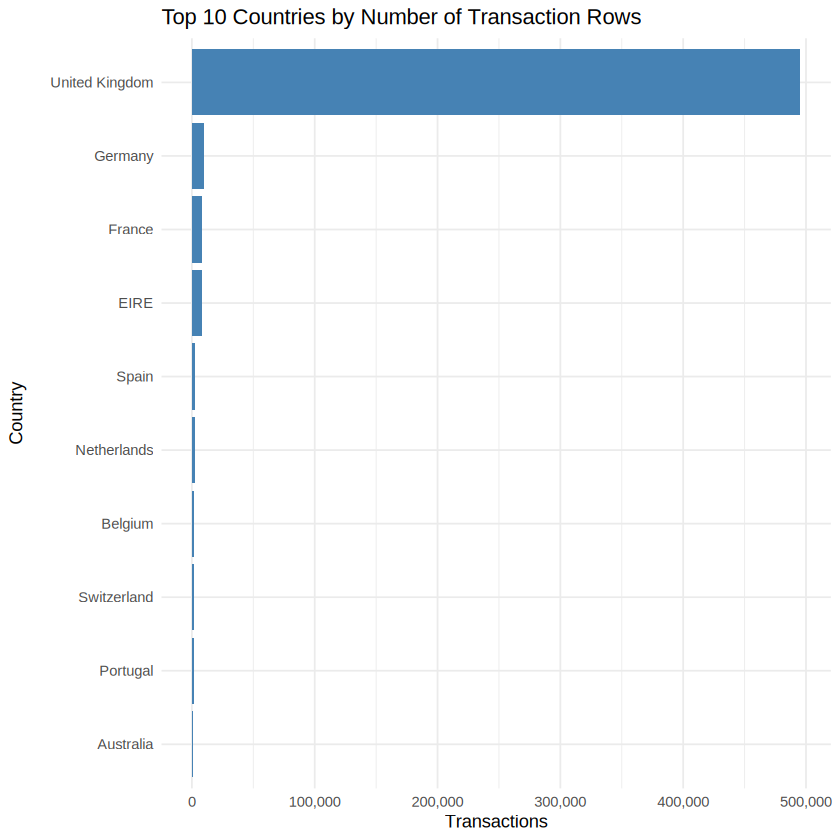

In [5]:
library(ggplot2)
library(scales)

country_counts <- sort(table(raw$Country), decreasing = TRUE)
top_countries <- head(as.data.frame(country_counts), 10)
names(top_countries) <- c("Country", "Transactions")

ggplot(top_countries, aes(x = reorder(Country, Transactions), y = Transactions)) +
  geom_col(fill = "steelblue") +
  coord_flip() +
  scale_y_continuous(labels = comma) +
  labs(title = "Top 10 Countries by Number of Transaction Rows",
       x = "Country", y = "Transactions") +
  theme_minimal()

## 4. Data Cleaning

Cleaning decisions:

* **Missing values:** rows with no `CustomerID` cannot be assigned to a customer, so they are removed.
* **Cancellations:** invoices starting with `C` and rows with negative quantity are removed.
* **Invalid prices:** rows with a unit price of zero or less are removed (free items, adjustments).
* **Non-product stock codes:** postage, bank charges, manual entries, discounts and similar service codes are removed because they do not represent customer purchases of products.

In [6]:
non_product_codes <- c("POST", "DOT", "M", "BANK CHARGES", "C2", "PADS",
                       "AMAZONFEE", "CRUK", "D", "S", "B")

n_start <- nrow(raw)

step1 <- raw[!is.na(raw$CustomerID), ]
n1 <- nrow(step1)

step2 <- step1[!grepl("^C", step1$InvoiceNo), ]
n2 <- nrow(step2)

step3 <- step2[step2$Quantity > 0 & step2$UnitPrice > 0, ]
n3 <- nrow(step3)

step4 <- step3[!(toupper(step3$StockCode) %in% non_product_codes), ]
n4 <- nrow(step4)

df <- step4
df$CustomerID <- as.character(as.integer(df$CustomerID))
df$TotalPrice <- df$Quantity * df$UnitPrice
df$Date <- as.Date(df$InvoiceDate)

cleaning_log <- data.frame(
  Step = c("Original data", "Remove missing CustomerID", "Remove cancellations",
           "Remove non-positive quantity/price", "Remove non-product stock codes"),
  RowsRemaining = c(n_start, n1, n2, n3, n4),
  RowsRemoved = c(0, n_start - n1, n1 - n2, n2 - n3, n3 - n4)
)
print(cleaning_log)
cat("\nUnique customers after cleaning:", length(unique(df$CustomerID)), "\n")

                                Step RowsRemaining RowsRemoved
1                      Original data        541909           0
2          Remove missing CustomerID        406829      135080
3               Remove cancellations        397924        8905
4 Remove non-positive quantity/price        397884          40
5     Remove non-product stock codes        396337        1547

Unique customers after cleaning: 4334 


## 5. Customer-Level Feature Engineering

Features built for every customer:

| Feature | Meaning |
|---|---|
| Recency | Days since the last purchase, measured from a snapshot date (one day after the last invoice in the data) |
| Frequency | Number of distinct invoices |
| Monetary | Total spend |
| AvgTransactionValue | Average value of an invoice (Monetary / Frequency) |
| TotalQuantity | Total number of items bought |
| PurchaseFrequency | Invoices per month of active customer life |
| UniqueProducts | Number of distinct products purchased |
| AvgUnitPrice | Average price of the items bought |
| TenureDays | Days between first and last purchase |
| IsUK | 1 if the customer is from the United Kingdom |

The first six features are used for clustering. The last four are additional behavioural features that are used later
in the supervised prediction stage.

In [8]:
library(dplyr)

snapshot_date <- max(df$Date) + 1
cat("Snapshot date used for Recency:", format(snapshot_date), "\n")

# Invoice-level table
invoice_tbl <- df %>%
  group_by(CustomerID, InvoiceNo) %>%
  summarise(InvoiceValue = sum(TotalPrice),
            InvoiceQty   = sum(Quantity),
            InvoiceDate  = max(Date),
            .groups = "drop")

# RFM and related features
cust <- invoice_tbl %>%
  group_by(CustomerID) %>%
  summarise(Recency             = as.numeric(snapshot_date - max(InvoiceDate)),
            Frequency           = n(),
            Monetary            = sum(InvoiceValue),
            AvgTransactionValue = mean(InvoiceValue),
            TotalQuantity       = sum(InvoiceQty),
            FirstPurchase       = min(InvoiceDate),
            LastPurchase        = max(InvoiceDate),
            .groups = "drop") %>%
  mutate(TenureDays        = as.numeric(LastPurchase - FirstPurchase),
         PurchaseFrequency = Frequency / ((TenureDays / 30) + 1))

# Additional product and country features
prod_tbl <- df %>%
  group_by(CustomerID) %>%
  summarise(UniqueProducts = n_distinct(StockCode),
            AvgUnitPrice   = mean(UnitPrice),
            Country        = names(sort(table(Country), decreasing = TRUE))[1],
            .groups = "drop") %>%
  mutate(IsUK = as.integer(Country == "United Kingdom"))

cust <- as.data.frame(left_join(cust, prod_tbl, by = "CustomerID"))

cluster_vars <- c("Recency", "Frequency", "Monetary",
                  "AvgTransactionValue", "TotalQuantity", "PurchaseFrequency")

cat("Customer-level table:", nrow(cust), "customers,", ncol(cust), "columns\n\n")
head(cust)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




Snapshot date used for Recency: 2011-12-10 
Customer-level table: 4334 customers, 14 columns



,CustomerID,Recency,Frequency,Monetary,AvgTransactionValue,TotalQuantity,FirstPurchase,LastPurchase,TenureDays,PurchaseFrequency,UniqueProducts,AvgUnitPrice,Country,IsUK
,<chr>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<date>,<date>,<dbl>,<dbl>,<int>,<dbl>,<chr>,<int>
1,12346,326,1,77183.60,77183.6000,74215,2011-01-18,2011-01-18,0,1.0000000,1,1.040000,United Kingdom,1
2,12347,3,7,4310.00,615.7143,2458,2010-12-07,2011-12-07,365,0.5316456,103,2.644011,Iceland,0
3,12348,76,4,1437.24,359.3100,2332,2010-12-16,2011-09-25,283,0.3833866,21,0.692963,Finland,0
4,12349,19,1,1457.55,1457.5500,630,2011-11-21,2011-11-21,0,1.0000000,72,4.237500,Italy,0
5,12350,311,1,294.40,294.4000,196,2011-02-02,2011-02-02,0,1.0000000,16,1.581250,Norway,0
6,12352,37,7,1385.74,197.9629,526,2011-02-16,2011-11-03,260,0.7241379,57,4.075455,Norway,0


In [9]:
print(summary(cust[, c(cluster_vars, "UniqueProducts", "AvgUnitPrice", "TenureDays")]))

    Recency         Frequency          Monetary         AvgTransactionValue
 Min.   :  1.00   Min.   :  1.000   Min.   :     3.75   Min.   :    3.75   
 1st Qu.: 18.00   1st Qu.:  1.000   1st Qu.:   305.56   1st Qu.:  178.19   
 Median : 51.00   Median :  2.000   Median :   668.12   Median :  290.44   
 Mean   : 93.23   Mean   :  4.246   Mean   :  2021.47   Mean   :  417.01   
 3rd Qu.:143.00   3rd Qu.:  5.000   3rd Qu.:  1631.62   3rd Qu.:  425.81   
 Max.   :374.00   Max.   :206.000   Max.   :279138.02   Max.   :84236.25   
 TotalQuantity      PurchaseFrequency UniqueProducts     AvgUnitPrice     
 Min.   :     1.0   Min.   : 0.1515   Min.   :   1.00   Min.   :  0.1225  
 1st Qu.:   160.0   1st Qu.: 0.5263   1st Qu.:  16.00   1st Qu.:  2.1478  
 Median :   379.0   Median : 1.0000   Median :  35.00   Median :  2.8259  
 Mean   :  1190.0   Mean   : 0.8961   Mean   :  61.43   Mean   :  3.4503  
 3rd Qu.:   991.8   3rd Qu.: 1.0000   3rd Qu.:  77.00   3rd Qu.:  3.6892  
 Max.   :196844.0 

## 6. Outlier Treatment, Transformation and Scaling

The RFM variables are strongly right-skewed because a few wholesale customers spend very large amounts.
Three steps are applied:

1. **Winsorization** at the 1st and 99th percentiles to cap extreme outliers.
2. **Log transformation** (`log1p`) to reduce skewness.
3. **Standardization** (z-score) so that all features contribute equally to distance-based algorithms.

In [10]:
winsorize <- function(x, p = c(0.01, 0.99)) {
  q <- quantile(x, p, na.rm = TRUE)
  pmin(pmax(x, q[1]), q[2])
}

# Winsorized copy of the clustering features (kept in original units for profiling)
cust_w <- cust
for (v in cluster_vars) cust_w[[v]] <- winsorize(cust[[v]])

# Log transform then scale
X_log <- log1p(cust_w[, cluster_vars])
X <- scale(X_log)

cat("Scaled matrix dimensions:", dim(X), "\n")
cat("Column means (should be about 0):\n"); print(round(colMeans(X), 4))
cat("Column SDs (should be 1):\n"); print(round(apply(X, 2, sd), 4))

Scaled matrix dimensions: 4334 6 
Column means (should be about 0):
            Recency           Frequency            Monetary AvgTransactionValue 
                  0                   0                   0                   0 
      TotalQuantity   PurchaseFrequency 
                  0                   0 
Column SDs (should be 1):
            Recency           Frequency            Monetary AvgTransactionValue 
                  1                   1                   1                   1 
      TotalQuantity   PurchaseFrequency 
                  1                   1 


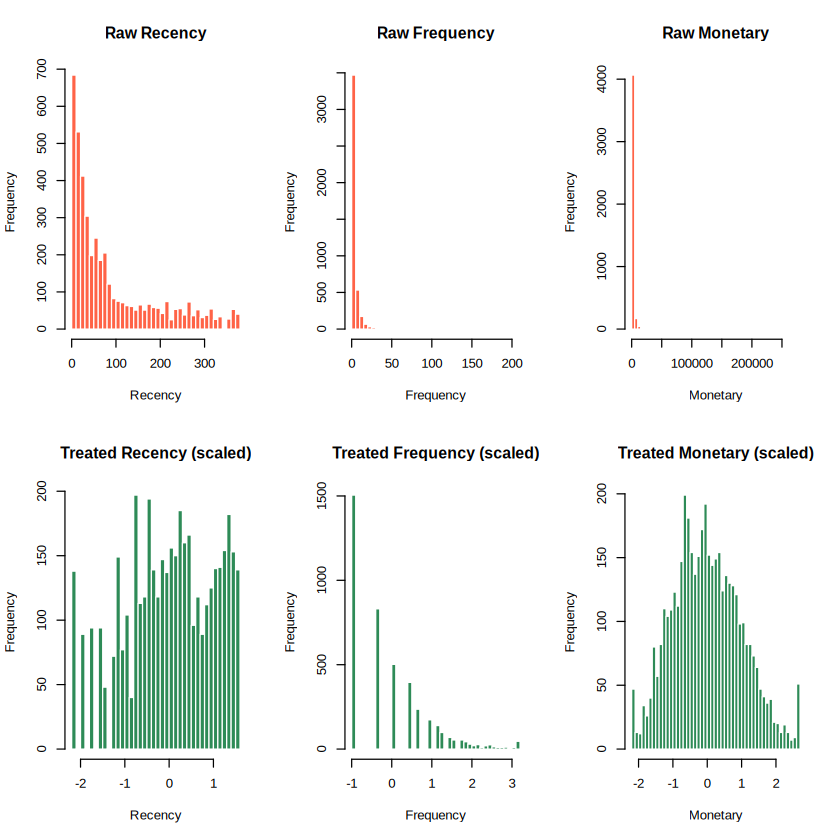

In [11]:
# Visual check: raw vs treated distributions
par(mfrow = c(2, 3))
for (v in c("Recency", "Frequency", "Monetary")) {
  hist(cust[[v]], breaks = 50, main = paste("Raw", v), xlab = v, col = "tomato", border = "white")
}
for (v in c("Recency", "Frequency", "Monetary")) {
  hist(X[, v], breaks = 50, main = paste("Treated", v, "(scaled)"), xlab = v, col = "seagreen", border = "white")
}
par(mfrow = c(1, 1))

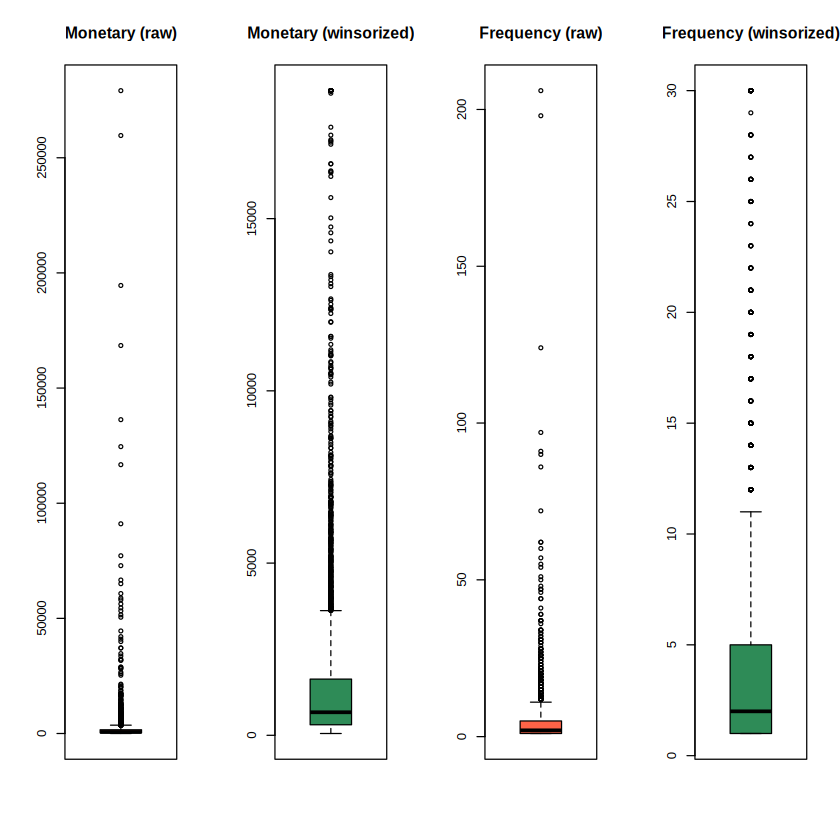

In [12]:
# Boxplots before and after winsorization for Monetary and Frequency
par(mfrow = c(1, 4))
boxplot(cust$Monetary,   main = "Monetary (raw)",        col = "tomato")
boxplot(cust_w$Monetary, main = "Monetary (winsorized)", col = "seagreen")
boxplot(cust$Frequency,   main = "Frequency (raw)",        col = "tomato")
boxplot(cust_w$Frequency, main = "Frequency (winsorized)", col = "seagreen")
par(mfrow = c(1, 1))

                    Recency Frequency Monetary AvgTransactionValue
Recency                1.00     -0.57    -0.49               -0.13
Frequency             -0.57      1.00     0.81                0.17
Monetary              -0.49      0.81     1.00                0.70
AvgTransactionValue   -0.13      0.17     0.70                1.00
TotalQuantity         -0.49      0.76     0.93                0.64
PurchaseFrequency      0.00      0.12     0.04               -0.01
                    TotalQuantity PurchaseFrequency
Recency                     -0.49              0.00
Frequency                    0.76              0.12
Monetary                     0.93              0.04
AvgTransactionValue          0.64             -0.01
TotalQuantity                1.00              0.02
PurchaseFrequency            0.02              1.00


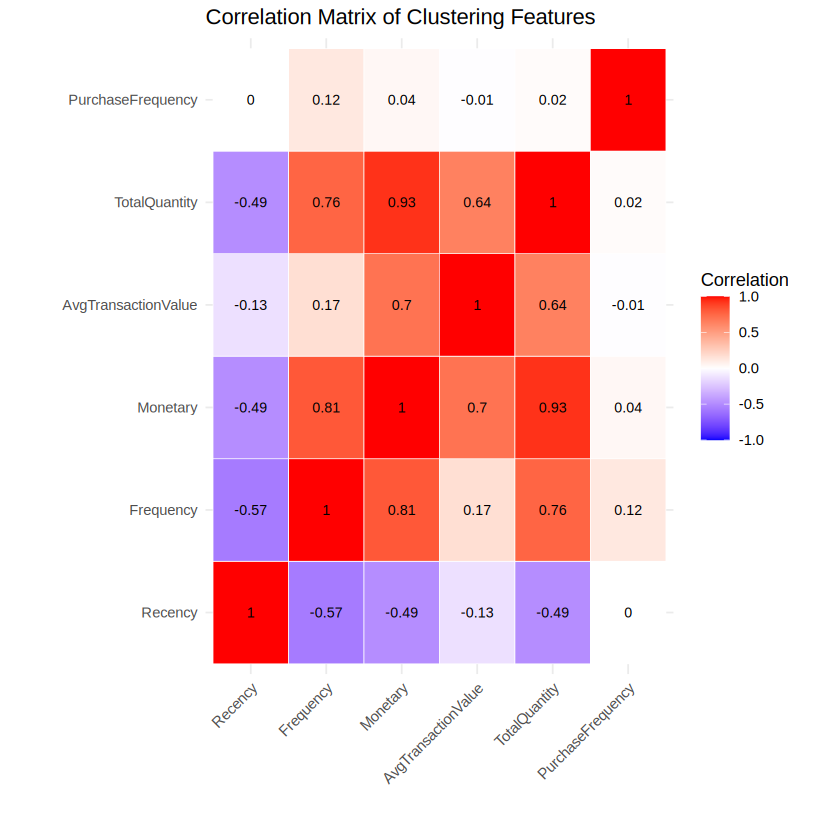

In [13]:
# Correlation between the clustering features
cor_mat <- round(cor(X), 2)
print(cor_mat)

cor_df <- as.data.frame(as.table(cor_mat))
names(cor_df) <- c("Var1", "Var2", "Correlation")
ggplot(cor_df, aes(Var1, Var2, fill = Correlation)) +
  geom_tile(color = "white") +
  geom_text(aes(label = Correlation), size = 3) +
  scale_fill_gradient2(low = "blue", mid = "white", high = "red", limits = c(-1, 1)) +
  labs(title = "Correlation Matrix of Clustering Features", x = "", y = "") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

## 7. Elbow Method and Optimal Number of Clusters

The Elbow Method plots the total within-cluster sum of squares (WSS) against the number of clusters k.
The "elbow", where the curve stops dropping sharply, indicates a good k. The average silhouette width is also
computed for each k as a supporting measure.

    k       WSS
1   1 25998.000
2   2 16344.540
3   3 12843.667
4   4 10898.906
5   5  9511.322
6   6  8609.509
7   7  7909.970
8   8  7368.237
9   9  6890.666
10 10  6504.563


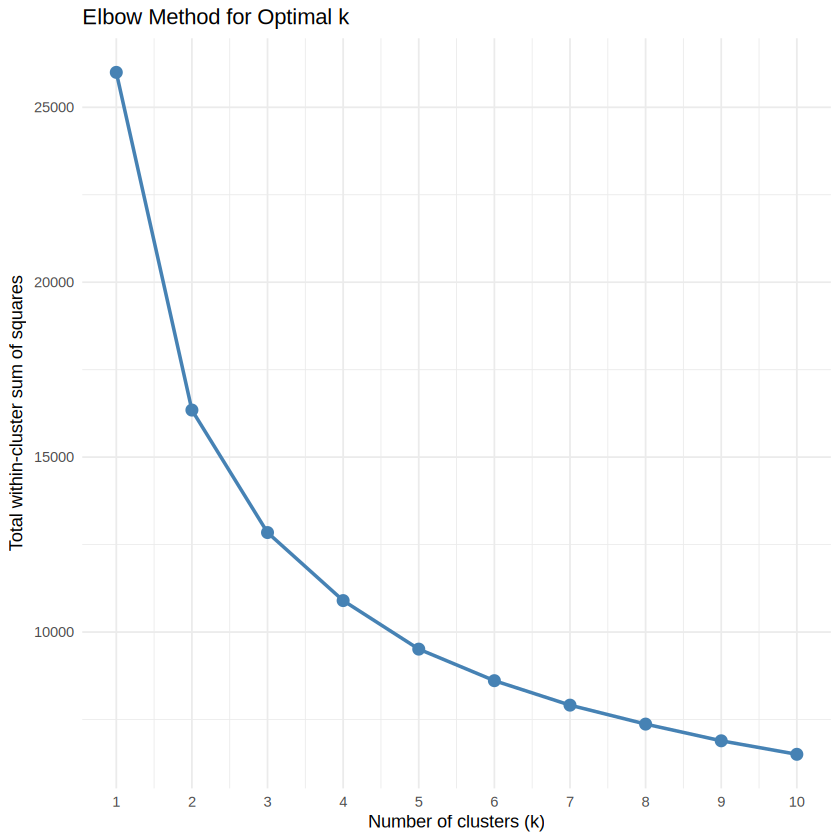

In [14]:
set.seed(123)
k_range <- 1:10
wss <- sapply(k_range, function(k) {
  kmeans(X, centers = k, nstart = 25, iter.max = 100)$tot.withinss
})

elbow_df <- data.frame(k = k_range, WSS = wss)
print(elbow_df)

ggplot(elbow_df, aes(x = k, y = WSS)) +
  geom_line(color = "steelblue", linewidth = 1) +
  geom_point(size = 3, color = "steelblue") +
  scale_x_continuous(breaks = k_range) +
  labs(title = "Elbow Method for Optimal k",
       x = "Number of clusters (k)", y = "Total within-cluster sum of squares") +
  theme_minimal()

   k AvgSilhouette
1  2     0.3255081
2  3     0.2823432
3  4     0.2626765
4  5     0.2552444
5  6     0.2534175
6  7     0.2500777
7  8     0.2376044
8  9     0.2340234
9 10     0.2311069


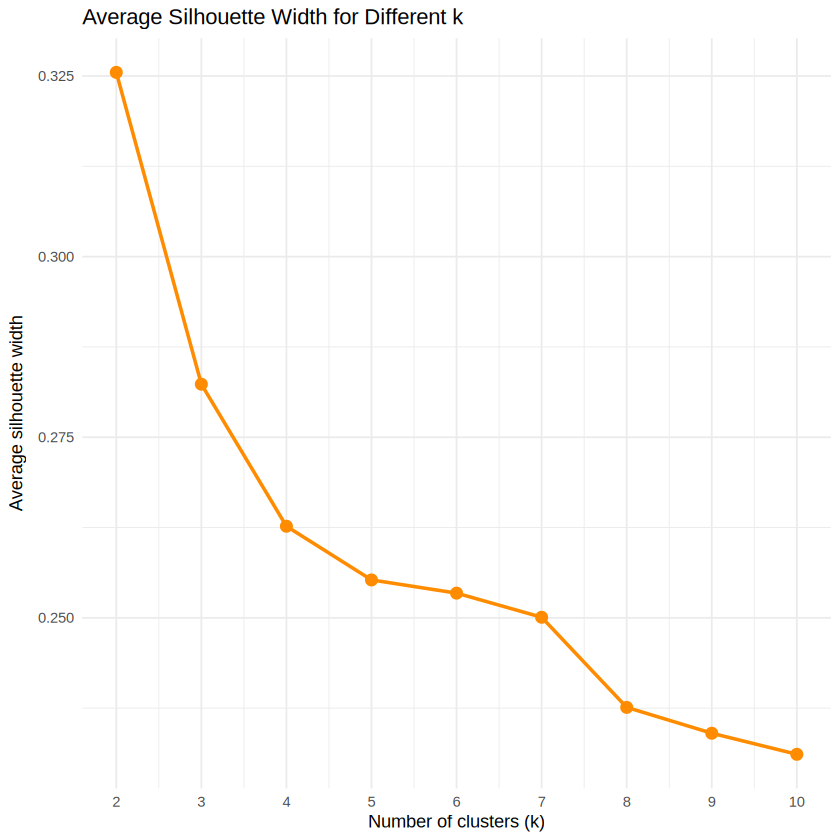

In [16]:
# Average silhouette width for k = 2..10
library(cluster)

dist_mat <- dist(X)

set.seed(123)
sil_k <- sapply(2:10, function(k) {
  km_tmp <- kmeans(X, centers = k, nstart = 25, iter.max = 100)
  mean(silhouette(km_tmp$cluster, dist_mat)[, 3])
})
sil_df <- data.frame(k = 2:10, AvgSilhouette = sil_k)
print(sil_df)

ggplot(sil_df, aes(x = k, y = AvgSilhouette)) +
  geom_line(color = "darkorange", linewidth = 1) +
  geom_point(size = 3, color = "darkorange") +
  scale_x_continuous(breaks = 2:10) +
  labs(title = "Average Silhouette Width for Different k",
       x = "Number of clusters (k)", y = "Average silhouette width") +
  theme_minimal()

In [17]:
# Choose k. A business segmentation needs more than 2 groups, so the search is limited to k = 3..6
# and the k with the best silhouette in that range is selected.
# You may override K_OPT manually after looking at the elbow plot, for example: K_OPT <- 4
K_OPT <- (3:6)[which.max(sil_df$AvgSilhouette[sil_df$k %in% 3:6])]
cat("Selected number of clusters (K_OPT):", K_OPT, "\n")

Selected number of clusters (K_OPT): 3 


## 8. K-Means Customer Segmentation

In [18]:
set.seed(123)
km <- kmeans(X, centers = K_OPT, nstart = 50, iter.max = 200)
cust$KMeans <- km$cluster

cat("K-Means cluster sizes:\n")
print(table(cust$KMeans))
cat("\nBetween-cluster SS / Total SS:", round(km$betweenss / km$totss, 4), "\n")

sil_km <- silhouette(km$cluster, dist_mat)
avg_sil_km <- mean(sil_km[, 3])
cat("Average silhouette score (K-Means):", round(avg_sil_km, 4), "\n")

K-Means cluster sizes:

   1    2    3 
 734 1759 1841 

Between-cluster SS / Total SS: 0.506 
Average silhouette score (K-Means): 0.2823 


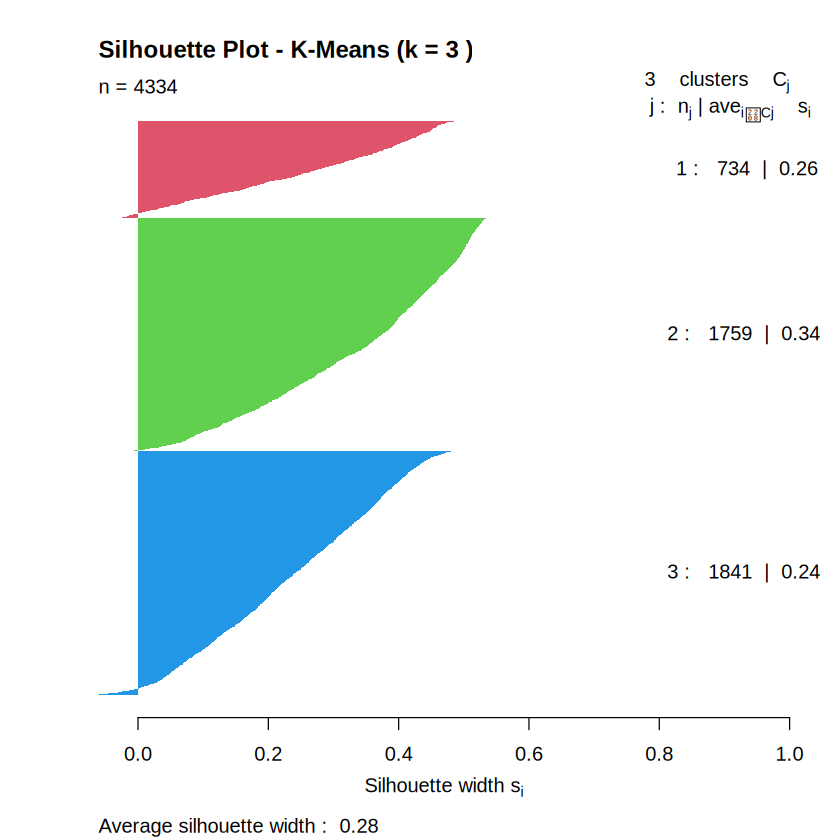

In [19]:
# Silhouette plot for K-Means
plot(sil_km, col = 2:(K_OPT + 1), border = NA,
     main = paste("Silhouette Plot - K-Means (k =", K_OPT, ")"))

## 9. Hierarchical Clustering and Dendrogram

Ward's method (`ward.D2`) is used on the same scaled data. The dendrogram is cut at the same number of clusters
as K-Means so the two results can be compared directly.

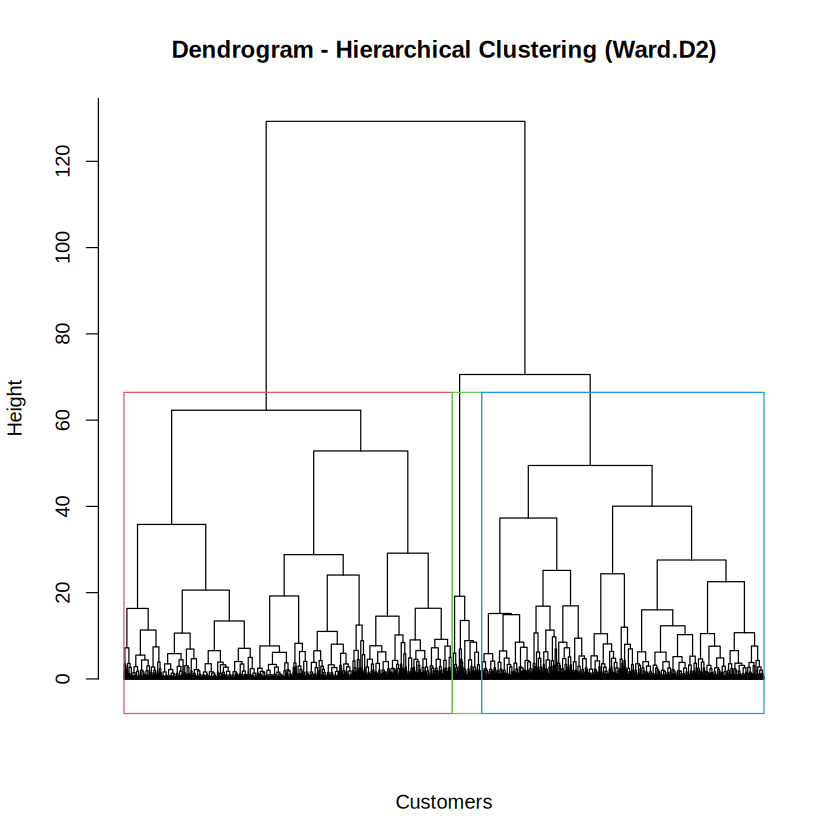

In [20]:
hc <- hclust(dist_mat, method = "ward.D2")

plot(hc, labels = FALSE, hang = -1,
     main = "Dendrogram - Hierarchical Clustering (Ward.D2)",
     xlab = "Customers", sub = "")
rect.hclust(hc, k = K_OPT, border = 2:(K_OPT + 1))

In [21]:
cust$Hier <- cutree(hc, k = K_OPT)

cat("Hierarchical cluster sizes:\n")
print(table(cust$Hier))

sil_hc <- silhouette(cust$Hier, dist_mat)
avg_sil_hc <- mean(sil_hc[, 3])
cat("\nAverage silhouette score (Hierarchical):", round(avg_sil_hc, 4), "\n")

Hierarchical cluster sizes:

   1    2    3 
2223 1912  199 

Average silhouette score (Hierarchical): 0.2553 


## 10. Silhouette Score and Comparison of Clustering Results

The two methods are compared using:

* the average silhouette score (higher is better, range -1 to 1),
* a cross-tabulation of the cluster assignments,
* the Adjusted Rand Index (ARI), which measures agreement between the two partitions (1 means identical, 0 means random agreement).

In [22]:
adj_rand <- function(a, b) {
  tab <- table(a, b)
  n <- sum(tab)
  comb2 <- function(x) x * (x - 1) / 2
  sum_ij <- sum(comb2(tab))
  sum_a <- sum(comb2(rowSums(tab)))
  sum_b <- sum(comb2(colSums(tab)))
  expected <- sum_a * sum_b / comb2(n)
  (sum_ij - expected) / (0.5 * (sum_a + sum_b) - expected)
}

ari <- adj_rand(cust$KMeans, cust$Hier)

comparison <- data.frame(
  Method = c("K-Means", "Hierarchical (Ward.D2)"),
  Clusters = c(K_OPT, K_OPT),
  AvgSilhouette = round(c(avg_sil_km, avg_sil_hc), 4)
)
print(comparison)

cat("\nAdjusted Rand Index between K-Means and Hierarchical:", round(ari, 4), "\n")
cat("\nCross-tabulation (rows = K-Means, columns = Hierarchical):\n")
print(table(KMeans = cust$KMeans, Hierarchical = cust$Hier))

better <- comparison$Method[which.max(comparison$AvgSilhouette)]
cat("\nMethod with the higher average silhouette score:", better, "\n")

                  Method Clusters AvgSilhouette
1                K-Means        3        0.2823
2 Hierarchical (Ward.D2)        3        0.2553

Adjusted Rand Index between K-Means and Hierarchical: 0.4161 

Cross-tabulation (rows = K-Means, columns = Hierarchical):
      Hierarchical
KMeans    1    2    3
     1   11  524  199
     2 1681   78    0
     3  531 1310    0

Method with the higher average silhouette score: K-Means 


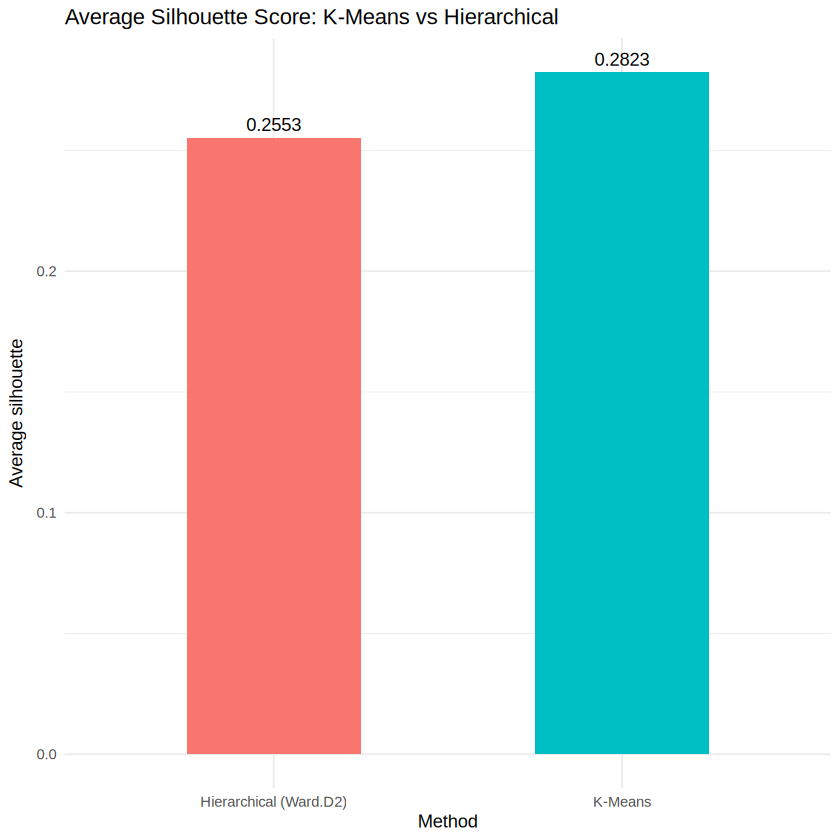

In [23]:
ggplot(comparison, aes(x = Method, y = AvgSilhouette, fill = Method)) +
  geom_col(width = 0.5) +
  geom_text(aes(label = AvgSilhouette), vjust = -0.5) +
  labs(title = "Average Silhouette Score: K-Means vs Hierarchical", y = "Average silhouette") +
  theme_minimal() +
  theme(legend.position = "none")

## 11. Cluster Profiling and Segment Naming

The K-Means result is used as the final segmentation. Each cluster is profiled using the winsorized feature values
in their original units, and a name is assigned using the cluster centres in scaled space:

* A composite score `Frequency + Monetary - Recency` identifies the **high-value** cluster (highest score) and the **lowest-value** cluster (lowest score).
* The remaining clusters are named by recency: recent buyers become "Developing Regulars", while less recent ones become "At-Risk / Lapsing".

In [24]:
# Cluster centres in scaled space
ctr <- aggregate(as.data.frame(X), by = list(Cluster = km$cluster), FUN = mean)
ctr$Score <- ctr$Frequency + ctr$Monetary - ctr$Recency

hv_cluster <- ctr$Cluster[which.max(ctr$Score)]
lv_cluster <- ctr$Cluster[which.min(ctr$Score)]

ctr$Label <- ifelse(ctr$Cluster == hv_cluster, "High-Value Champions",
              ifelse(ctr$Cluster == lv_cluster, "Dormant / Low-Value",
               ifelse(ctr$Recency < 0, "Developing Regulars", "At-Risk / Lapsing")))
ctr$Segment <- paste0("C", ctr$Cluster, ": ", ctr$Label)

cust$Segment <- factor(ctr$Segment[match(cust$KMeans, ctr$Cluster)])
cust_w$Segment <- cust$Segment

cat("High-value cluster (K-Means id):", hv_cluster, "\n")
print(ctr[, c("Cluster", "Recency", "Frequency", "Monetary", "Score", "Segment")])

High-value cluster (K-Means id): 1 
  Cluster    Recency   Frequency   Monetary      Score                  Segment
1       1 -1.0861249  1.62271582  1.4264628  4.1353035 C1: High-Value Champions
2       2  0.6075926 -0.75613784 -0.9177497 -2.2814801  C2: Dormant / Low-Value
3       3 -0.1474957  0.07548781  0.3081467  0.5311302  C3: Developing Regulars


In [25]:
total_revenue <- sum(cust$Monetary)

profile <- cust_w %>%
  group_by(Segment) %>%
  summarise(Customers           = n(),
            Recency             = mean(Recency),
            Frequency           = mean(Frequency),
            Monetary            = mean(Monetary),
            AvgTransactionValue = mean(AvgTransactionValue),
            TotalQuantity       = mean(TotalQuantity),
            PurchaseFrequency   = mean(PurchaseFrequency),
            .groups = "drop")

rev_tbl <- cust %>%
  group_by(Segment) %>%
  summarise(RevenueShare = 100 * sum(Monetary) / total_revenue, .groups = "drop")

profile <- as.data.frame(left_join(profile, rev_tbl, by = "Segment"))
profile$CustomerShare <- round(100 * profile$Customers / sum(profile$Customers), 1)
profile[, 3:9] <- round(profile[, 3:9], 2)

cat("Cluster profiles (means, winsorized original units):\n")
print(profile)

Cluster profiles (means, winsorized original units):
                   Segment Customers Recency Frequency Monetary
1 C1: High-Value Champions       734   19.77     11.85  5378.02
2  C2: Dormant / Low-Value      1759  155.63      1.40   280.52
3  C3: Developing Regulars      1841   62.82      3.32  1264.91
  AvgTransactionValue TotalQuantity PurchaseFrequency RevenueShare
1              498.51       3131.67              1.28        67.13
2              222.33        161.60              1.00         5.62
3              441.88        774.45              0.59        27.25
  CustomerShare
1          16.9
2          40.6
3          42.5


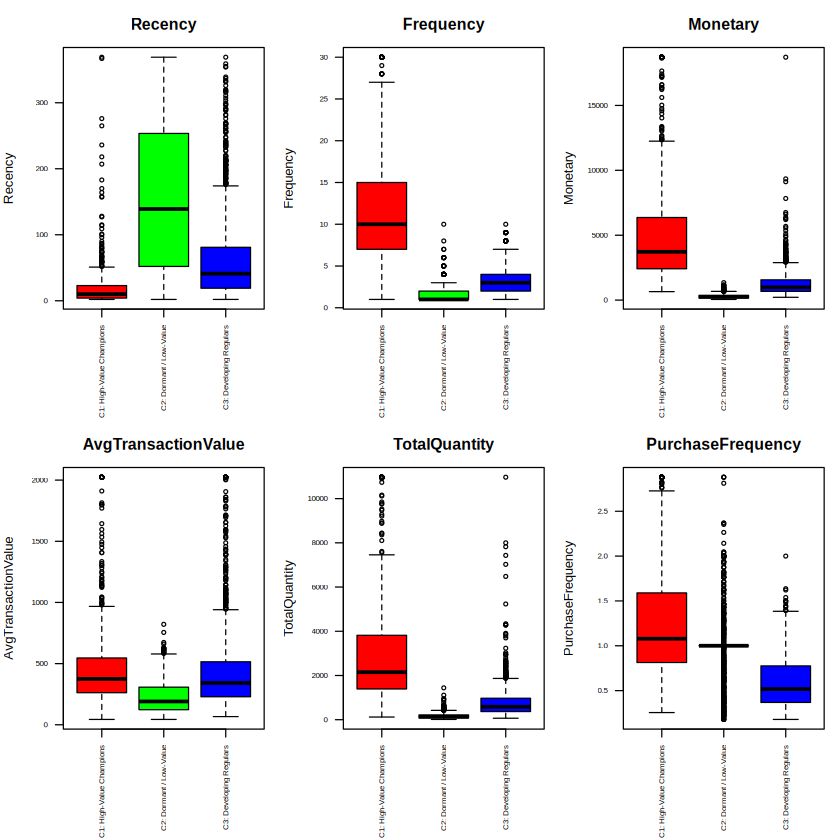

In [26]:
# Boxplots of key features by segment
seg_cols <- rainbow(K_OPT)
par(mfrow = c(2, 3), mar = c(7, 4, 3, 1))
for (v in cluster_vars) {
  boxplot(cust_w[[v]] ~ cust_w$Segment, main = v, xlab = "", ylab = v,
          las = 2, cex.axis = 0.6, col = seg_cols)
}
par(mfrow = c(1, 1), mar = c(5, 4, 4, 2))

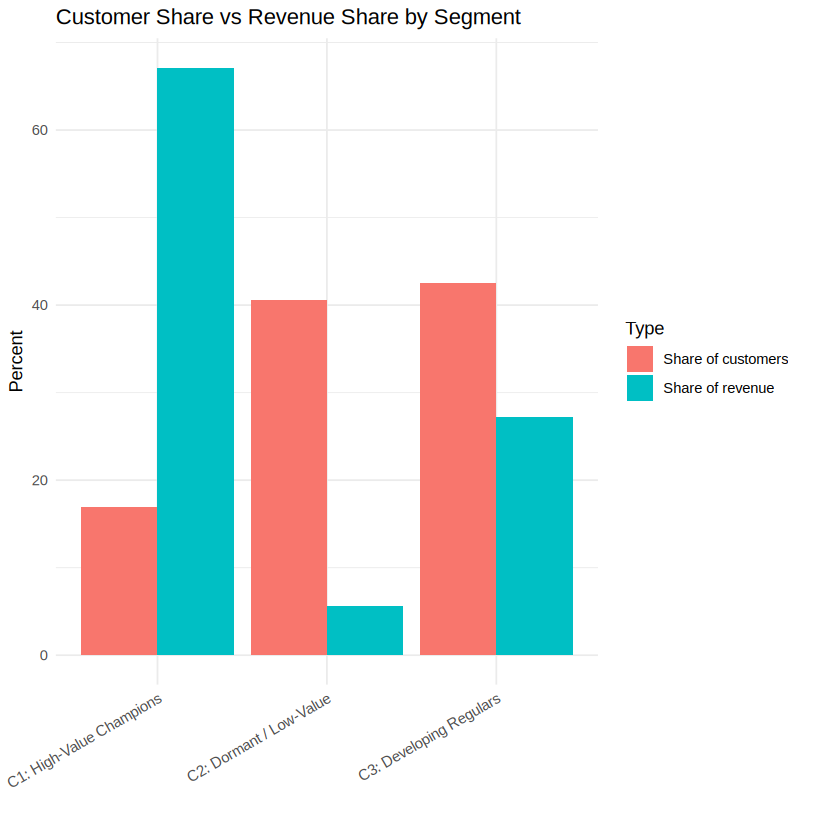

In [27]:
# Share of customers vs share of revenue for each segment
share_df <- data.frame(
  Segment = rep(profile$Segment, 2),
  Type = rep(c("Share of customers", "Share of revenue"), each = nrow(profile)),
  Percent = c(profile$CustomerShare, profile$RevenueShare)
)

ggplot(share_df, aes(x = Segment, y = Percent, fill = Type)) +
  geom_col(position = "dodge") +
  labs(title = "Customer Share vs Revenue Share by Segment", x = "", y = "Percent") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 30, hjust = 1))

## 12. PCA for Dimensionality Reduction and 2D Visualization

In [28]:
pca <- prcomp(X, center = FALSE, scale. = FALSE)

var_exp <- pca$sdev^2 / sum(pca$sdev^2)
pca_summary <- data.frame(PC = paste0("PC", seq_along(var_exp)),
                          VarianceExplained = round(var_exp, 4),
                          Cumulative = round(cumsum(var_exp), 4))
print(pca_summary)

cat("\nLoadings of the first three components:\n")
print(round(pca$rotation[, 1:3], 3))

   PC VarianceExplained Cumulative
1 PC1            0.5627     0.5627
2 PC2            0.1782     0.7408
3 PC3            0.1627     0.9036
4 PC4            0.0790     0.9825
5 PC5            0.0165     0.9991
6 PC6            0.0009     1.0000

Loadings of the first three components:
                       PC1    PC2    PC3
Recency             -0.345  0.375 -0.440
Frequency            0.456 -0.361  0.167
Monetary             0.532  0.107 -0.072
AvgTransactionValue  0.347  0.587 -0.397
TotalQuantity        0.518  0.106 -0.047
PurchaseFrequency    0.035 -0.602 -0.783


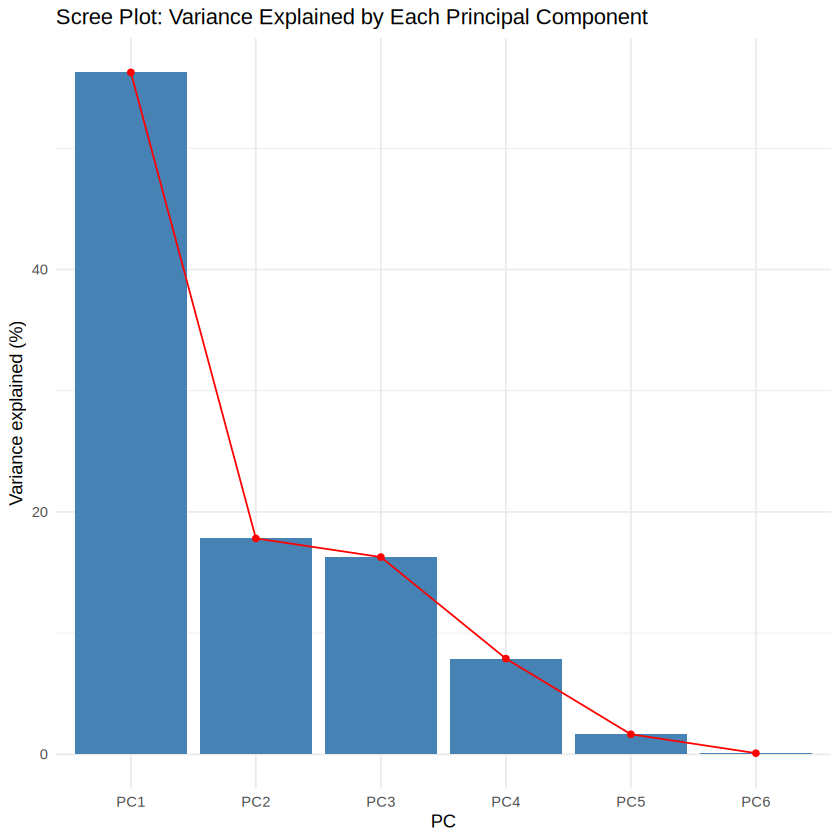

In [29]:
# Scree plot
scree_df <- data.frame(PC = factor(paste0("PC", seq_along(var_exp)), levels = paste0("PC", seq_along(var_exp))),
                       Variance = var_exp * 100)
ggplot(scree_df, aes(x = PC, y = Variance, group = 1)) +
  geom_col(fill = "steelblue") +
  geom_line(color = "red") +
  geom_point(color = "red") +
  labs(title = "Scree Plot: Variance Explained by Each Principal Component",
       y = "Variance explained (%)") +
  theme_minimal()

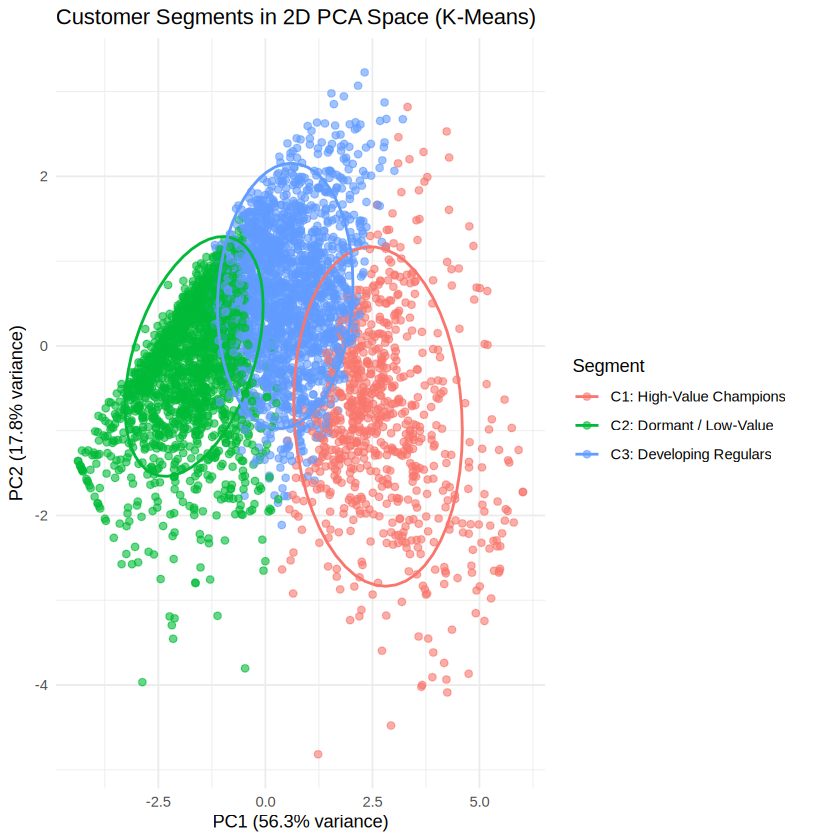

In [30]:
pca_df <- data.frame(PC1 = pca$x[, 1], PC2 = pca$x[, 2], PC3 = pca$x[, 3],
                     Segment = cust$Segment)

ggplot(pca_df, aes(x = PC1, y = PC2, color = Segment)) +
  geom_point(alpha = 0.6, size = 1.8) +
  stat_ellipse(level = 0.9, linewidth = 0.8) +
  labs(title = "Customer Segments in 2D PCA Space (K-Means)",
       x = paste0("PC1 (", round(100 * var_exp[1], 1), "% variance)"),
       y = paste0("PC2 (", round(100 * var_exp[2], 1), "% variance)")) +
  theme_minimal()

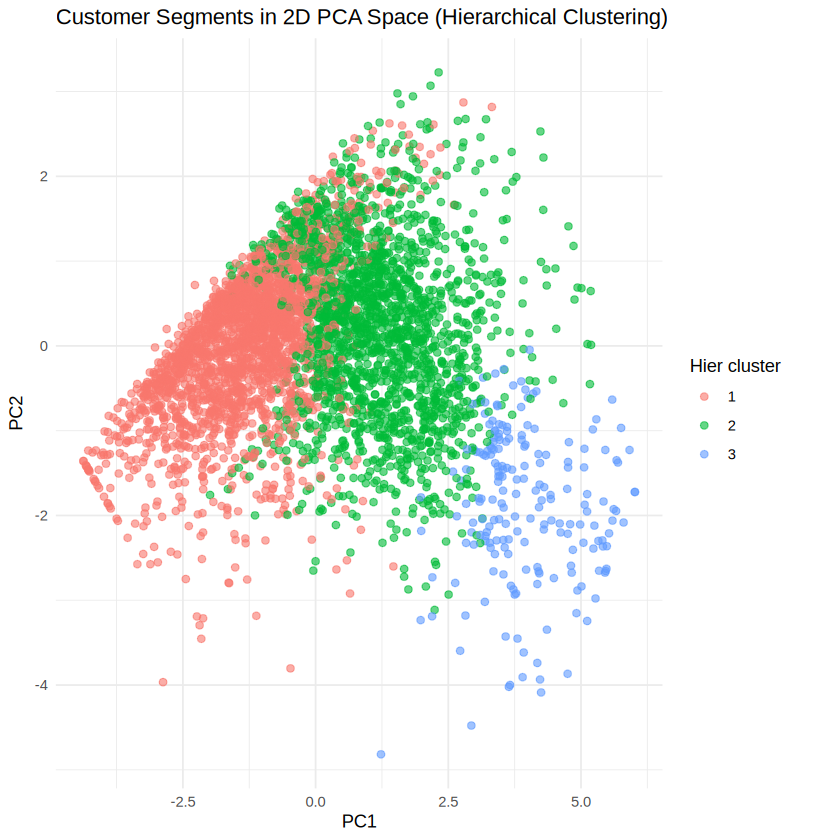

In [31]:
# Same projection coloured by hierarchical clusters for visual comparison
pca_df$Hier <- factor(cust$Hier)

ggplot(pca_df, aes(x = PC1, y = PC2, color = Hier)) +
  geom_point(alpha = 0.6, size = 1.8) +
  labs(title = "Customer Segments in 2D PCA Space (Hierarchical Clustering)",
       x = "PC1", y = "PC2", color = "Hier cluster") +
  theme_minimal()

## 13. High-Value Customer Prediction (Supervised Learning)

**Target variable:** `HighValue = Yes` if the customer belongs to the high-value K-Means cluster identified in Section 11, otherwise `No`.

**Models:** Random Forest and Support Vector Machine (RBF kernel, tuned by cross-validation).

**Important note on data leakage:** the target is defined using clusters that were built from the six clustering features.
Using those same features as predictors makes the task easy, so very high scores are expected. To give a more honest picture,
two experiments are run:

* **Experiment A (full feature set):** all clustering features plus extra behavioural features.
* **Experiment B (reduced feature set):** only the extra behavioural features that were **not** used for clustering (`UniqueProducts`, `AvgUnitPrice`, `TenureDays`, `IsUK`). This shows how well high-value status can be predicted without the defining features.

In [32]:
# Prepare predictors: winsorize and log-transform skewed variables
all_feats <- c(cluster_vars, "UniqueProducts", "AvgUnitPrice", "TenureDays", "IsUK")

feat_df <- cust[, all_feats]
for (v in setdiff(all_feats, "IsUK")) {
  feat_df[[v]] <- log1p(winsorize(feat_df[[v]]))
}

y <- factor(ifelse(cust$KMeans == hv_cluster, "Yes", "No"), levels = c("No", "Yes"))
cat("Class distribution of the target:\n")
print(table(y))
cat("Proportion of high-value customers:", round(mean(y == "Yes"), 3), "\n")

# Stratified 80/20 train-test split
set.seed(42)
idx_yes <- which(y == "Yes")
idx_no  <- which(y == "No")
train_idx <- c(sample(idx_yes, floor(0.8 * length(idx_yes))),
               sample(idx_no,  floor(0.8 * length(idx_no))))

cat("\nTraining rows:", length(train_idx), " Test rows:", nrow(feat_df) - length(train_idx), "\n")
print(table(y[train_idx]))
print(table(y[-train_idx]))

Class distribution of the target:
y
  No  Yes 
3600  734 
Proportion of high-value customers: 0.169 

Training rows: 3467  Test rows: 867 

  No  Yes 
2880  587 

 No Yes 
720 147 


In [33]:
# Evaluation helper
eval_model <- function(truth, prob, name, threshold = 0.5) {
  pred <- factor(ifelse(prob >= threshold, "Yes", "No"), levels = c("No", "Yes"))
  cm <- table(Predicted = pred, Actual = truth)
  TP <- cm["Yes", "Yes"]; TN <- cm["No", "No"]
  FP <- cm["Yes", "No"];  FN <- cm["No", "Yes"]
  accuracy  <- (TP + TN) / sum(cm)
  precision <- ifelse((TP + FP) == 0, 0, TP / (TP + FP))
  recall    <- ifelse((TP + FN) == 0, 0, TP / (TP + FN))
  f1        <- ifelse((precision + recall) == 0, 0, 2 * precision * recall / (precision + recall))
  roc_obj   <- roc(truth, prob, levels = c("No", "Yes"), direction = "<", quiet = TRUE)
  list(metrics = data.frame(Model = name,
                            Accuracy = round(accuracy, 4),
                            Precision = round(precision, 4),
                            Recall = round(recall, 4),
                            F1 = round(f1, 4),
                            ROC_AUC = round(as.numeric(auc(roc_obj)), 4)),
       cm = cm, roc = roc_obj)
}

# Training function used for both experiments
fit_models <- function(feats, label) {
  trx <- feat_df[train_idx, feats, drop = FALSE]
  tex <- feat_df[-train_idx, feats, drop = FALSE]
  try_ <- y[train_idx]
  tey  <- y[-train_idx]

  # Random Forest
  set.seed(42)
  rf_fit <- randomForest(x = trx, y = try_, ntree = 500, importance = TRUE)
  rf_prob <- predict(rf_fit, tex, type = "prob")[, "Yes"]

  # SVM with scaling based on training statistics
  mu <- colMeans(trx)
  sdv <- apply(trx, 2, sd); sdv[sdv == 0] <- 1
  trs <- as.data.frame(scale(trx, center = mu, scale = sdv))
  tes <- as.data.frame(scale(tex, center = mu, scale = sdv))

  set.seed(42)
  tuned <- tune(svm, train.x = trs, train.y = try_, kernel = "radial",
                ranges = list(cost = c(0.1, 1, 10), gamma = c(0.01, 0.1, 1)),
                tunecontrol = tune.control(cross = 5))
  svm_fit <- svm(x = trs, y = try_, kernel = "radial",
                 cost = tuned$best.parameters$cost,
                 gamma = tuned$best.parameters$gamma,
                 probability = TRUE)
  svm_pred <- predict(svm_fit, tes, probability = TRUE)
  svm_prob <- attr(svm_pred, "probabilities")[, "Yes"]

  rf_res  <- eval_model(tey, rf_prob,  paste("Random Forest", label))
  svm_res <- eval_model(tey, svm_prob, paste("SVM (RBF)", label))

  list(rf_fit = rf_fit, svm_fit = svm_fit, best_svm = tuned$best.parameters,
       rf = rf_res, svm = svm_res)
}

cat("Helper functions defined.\n")

Helper functions defined.


### Experiment A: Full Feature Set

In [37]:
library(randomForest)
library(e1071)

resA <- fit_models(all_feats, "(A: full features)")

cat("Best SVM parameters (cross-validation):\n")
print(resA$best_svm)

metricsA <- rbind(resA$rf$metrics, resA$svm$metrics)
cat("\nPerformance on the test set:\n")
print(metricsA)

Best SVM parameters (cross-validation):
  cost gamma
3   10  0.01

Performance on the test set:
                             Model Accuracy Precision Recall     F1 ROC_AUC
1 Random Forest (A: full features)   0.9827    0.9783 0.9184 0.9474  0.9981
2     SVM (RBF) (A: full features)   0.9988    1.0000 0.9932 0.9966  1.0000


Confusion Matrix - Random Forest (A)
         Actual
Predicted  No Yes
      No  717  12
      Yes   3 135

Confusion Matrix - SVM (A)
         Actual
Predicted  No Yes
      No  720   1
      Yes   0 146


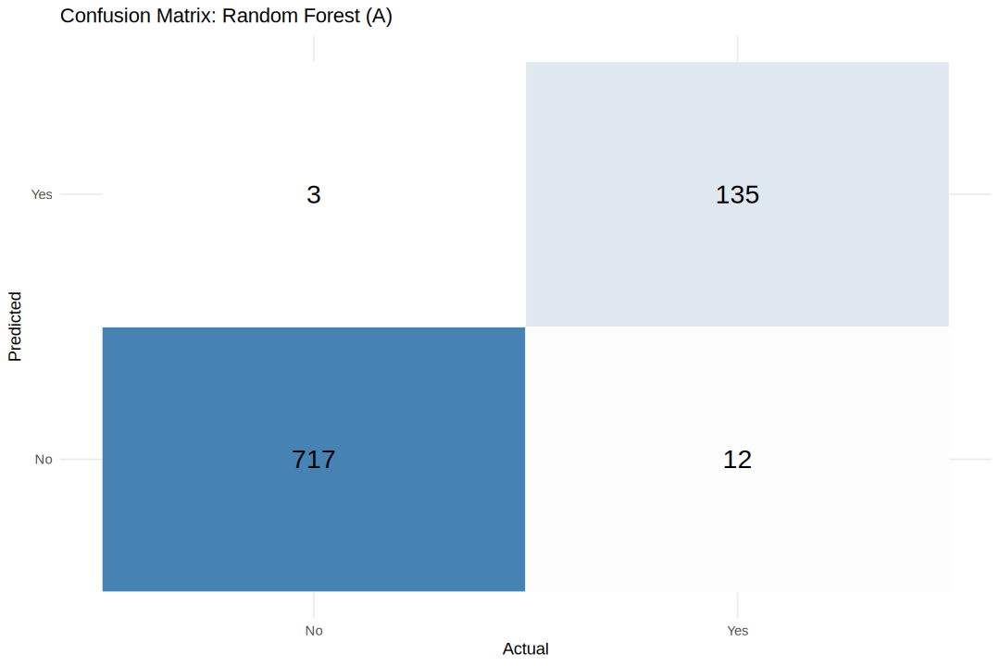

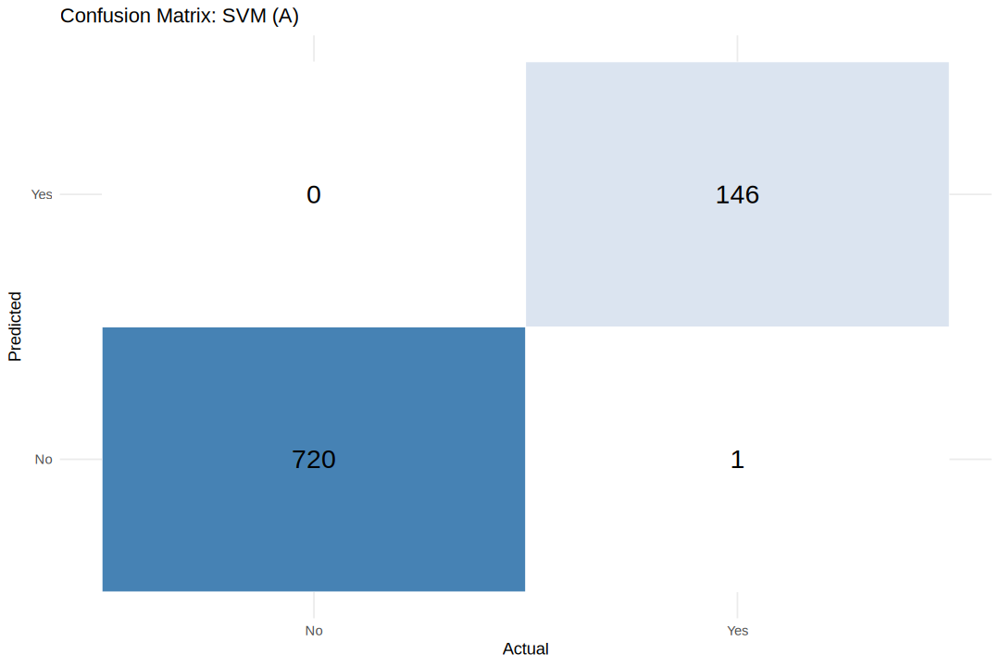

In [38]:
cat("Confusion Matrix - Random Forest (A)\n"); print(resA$rf$cm)
cat("\nConfusion Matrix - SVM (A)\n"); print(resA$svm$cm)

plot_cm <- function(cm, title) {
  df_cm <- as.data.frame(cm)
  ggplot(df_cm, aes(x = Actual, y = Predicted, fill = Freq)) +
    geom_tile(color = "white") +
    geom_text(aes(label = Freq), size = 6) +
    scale_fill_gradient(low = "white", high = "steelblue") +
    labs(title = title) +
    theme_minimal() +
    theme(legend.position = "none")
}

plot_cm(resA$rf$cm,  "Confusion Matrix: Random Forest (A)")
plot_cm(resA$svm$cm, "Confusion Matrix: SVM (A)")

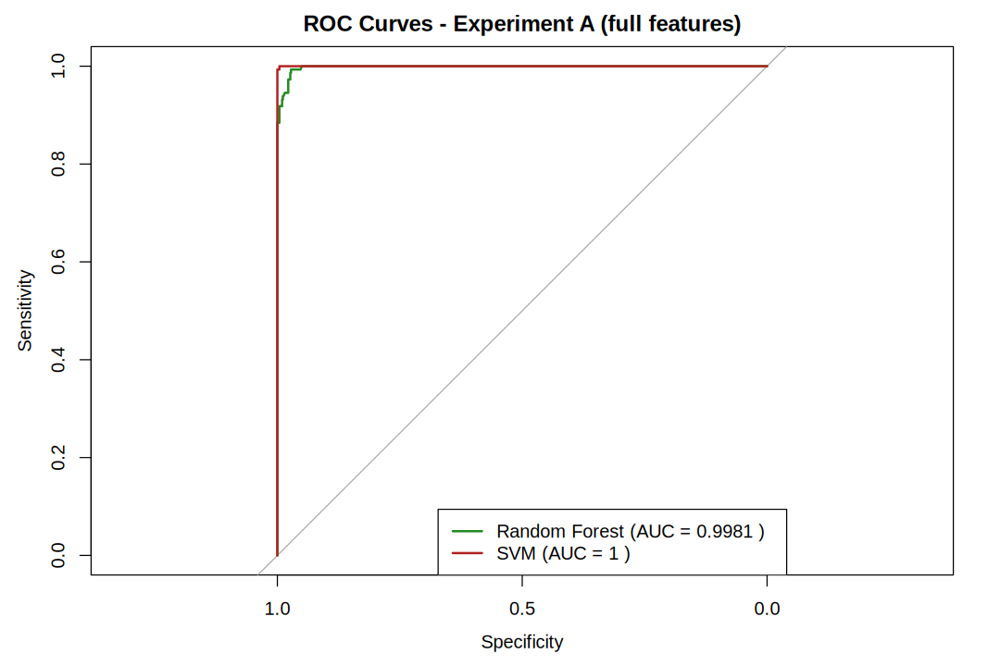

In [39]:
# ROC curves
plot(resA$rf$roc, col = "forestgreen", lwd = 2, main = "ROC Curves - Experiment A (full features)")
plot(resA$svm$roc, col = "firebrick", lwd = 2, add = TRUE)
legend("bottomright", lwd = 2, col = c("forestgreen", "firebrick"),
       legend = c(paste("Random Forest (AUC =", resA$rf$metrics$ROC_AUC, ")"),
                  paste("SVM (AUC =", resA$svm$metrics$ROC_AUC, ")")))

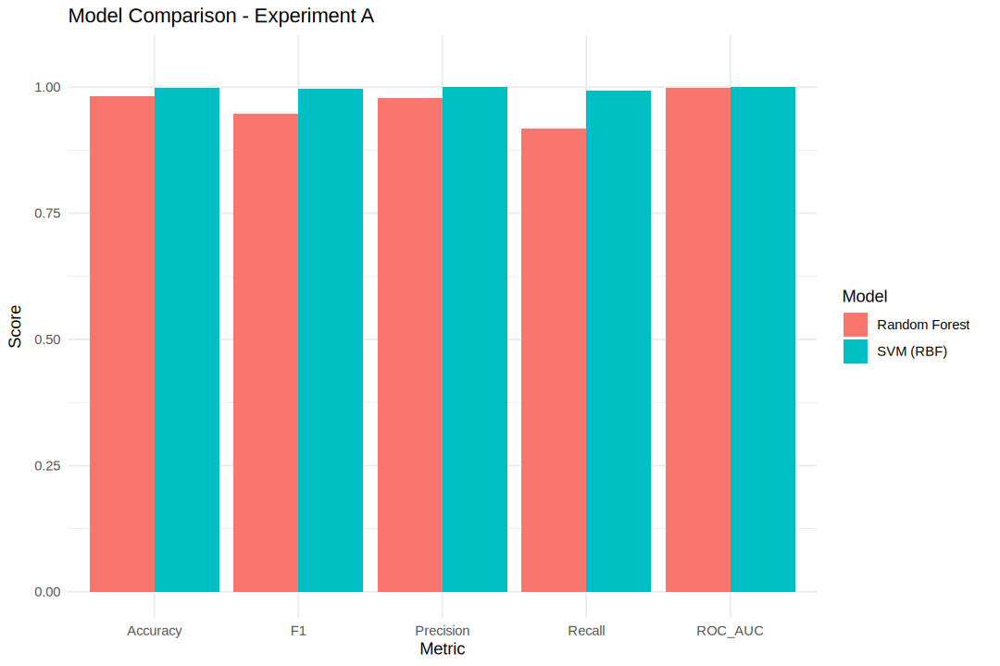

In [40]:
# Metric comparison chart
long_A <- data.frame(
  Model = rep(c("Random Forest", "SVM (RBF)"), each = 5),
  Metric = rep(c("Accuracy", "Precision", "Recall", "F1", "ROC_AUC"), 2),
  Value = c(unlist(resA$rf$metrics[, 2:6]), unlist(resA$svm$metrics[, 2:6]))
)

ggplot(long_A, aes(x = Metric, y = Value, fill = Model)) +
  geom_col(position = "dodge") +
  coord_cartesian(ylim = c(0, 1.05)) +
  labs(title = "Model Comparison - Experiment A", y = "Score") +
  theme_minimal()

### Experiment B: Reduced Feature Set (No Clustering Features)
This experiment checks whether high-value customers can still be identified using only behavioural features
that were not used to build the clusters.

In [41]:
reduced_feats <- c("UniqueProducts", "AvgUnitPrice", "TenureDays", "IsUK")
resB <- fit_models(reduced_feats, "(B: reduced features)")

metricsB <- rbind(resB$rf$metrics, resB$svm$metrics)
cat("Performance on the test set (reduced features):\n")
print(metricsB)

cat("\nConfusion Matrix - Random Forest (B)\n"); print(resB$rf$cm)
cat("\nConfusion Matrix - SVM (B)\n"); print(resB$svm$cm)

Performance on the test set (reduced features):
                                Model Accuracy Precision Recall     F1 ROC_AUC
1 Random Forest (B: reduced features)   0.8651    0.6210 0.5238 0.5683  0.8814
2     SVM (RBF) (B: reduced features)   0.8777    0.7412 0.4286 0.5431  0.7718

Confusion Matrix - Random Forest (B)
         Actual
Predicted  No Yes
      No  673  70
      Yes  47  77

Confusion Matrix - SVM (B)
         Actual
Predicted  No Yes
      No  698  84
      Yes  22  63


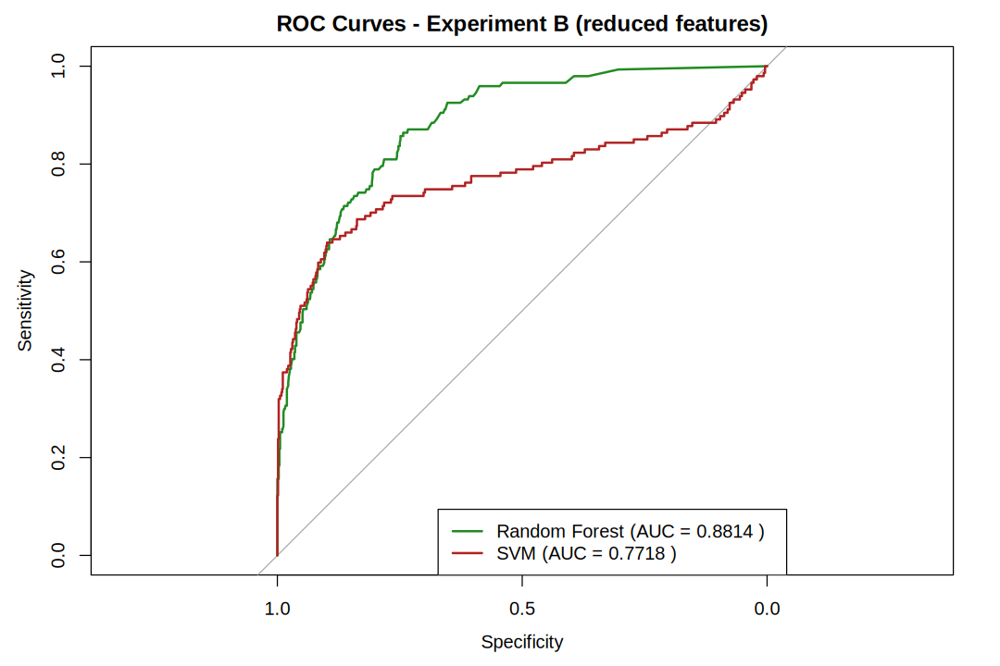

In [42]:
plot(resB$rf$roc, col = "forestgreen", lwd = 2, main = "ROC Curves - Experiment B (reduced features)")
plot(resB$svm$roc, col = "firebrick", lwd = 2, add = TRUE)
legend("bottomright", lwd = 2, col = c("forestgreen", "firebrick"),
       legend = c(paste("Random Forest (AUC =", resB$rf$metrics$ROC_AUC, ")"),
                  paste("SVM (AUC =", resB$svm$metrics$ROC_AUC, ")")))

In [43]:
# Final comparison table of all four models
all_metrics <- rbind(metricsA, metricsB)
rownames(all_metrics) <- NULL
cat("Overall performance comparison:\n")
print(all_metrics)

best_row <- all_metrics[which.max(all_metrics$ROC_AUC), ]
cat("\nBest model by ROC-AUC:", best_row$Model, "(AUC =", best_row$ROC_AUC, ")\n")

Overall performance comparison:
                                Model Accuracy Precision Recall     F1 ROC_AUC
1    Random Forest (A: full features)   0.9827    0.9783 0.9184 0.9474  0.9981
2        SVM (RBF) (A: full features)   0.9988    1.0000 0.9932 0.9966  1.0000
3 Random Forest (B: reduced features)   0.8651    0.6210 0.5238 0.5683  0.8814
4     SVM (RBF) (B: reduced features)   0.8777    0.7412 0.4286 0.5431  0.7718

Best model by ROC-AUC: SVM (RBF) (A: full features) (AUC = 1 )


## 14. Feature Importance Analysis
Random Forest provides two importance measures: Mean Decrease in Accuracy (permutation based) and
Mean Decrease in Gini (impurity based). Both are shown for the full-feature model and for the reduced-feature model.

                                Feature MeanDecreaseAccuracy MeanDecreaseGini
Frequency                     Frequency            46.948733        324.11568
Monetary                       Monetary            35.727721        191.65209
TotalQuantity             TotalQuantity            31.420182        152.13703
PurchaseFrequency     PurchaseFrequency            50.946859        108.58326
Recency                         Recency            44.639278         74.92753
TenureDays                   TenureDays            17.334144         43.85179
UniqueProducts           UniqueProducts            12.109020         39.75667
AvgTransactionValue AvgTransactionValue            23.492315         26.38822
AvgUnitPrice               AvgUnitPrice            12.342285         12.80274
IsUK                               IsUK             2.937497          1.32734


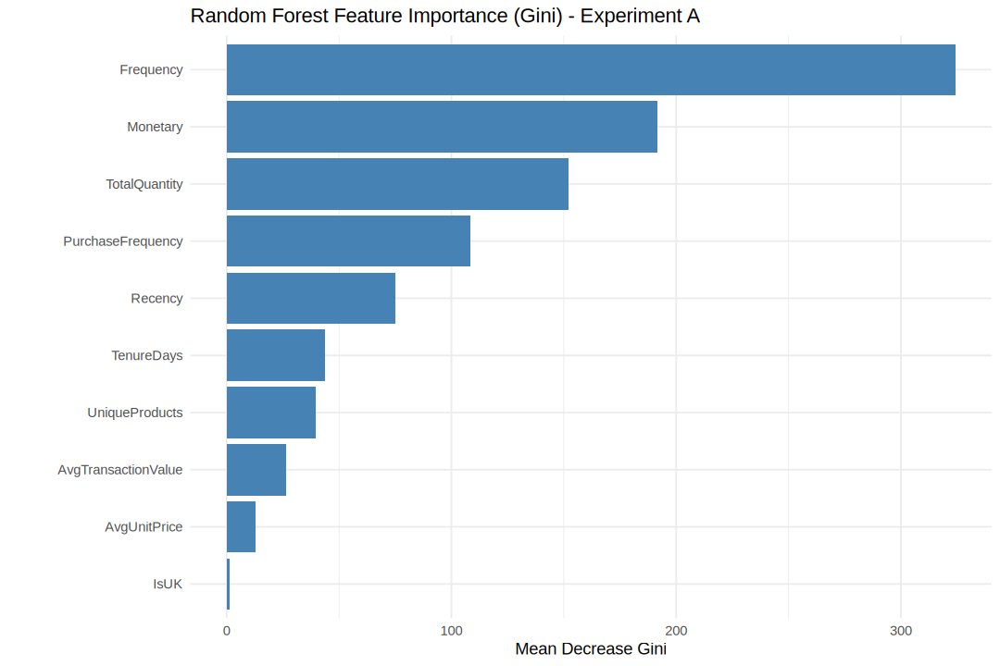

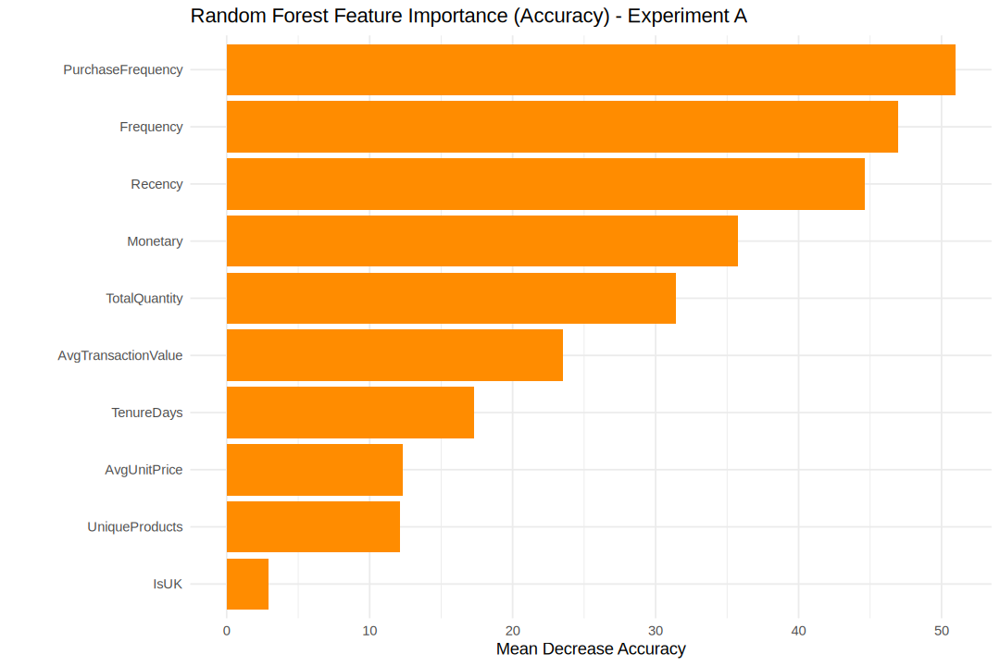

In [44]:
imp_A <- as.data.frame(importance(resA$rf_fit))
imp_A$Feature <- rownames(imp_A)
imp_A <- imp_A[order(imp_A$MeanDecreaseGini, decreasing = TRUE), ]
print(imp_A[, c("Feature", "MeanDecreaseAccuracy", "MeanDecreaseGini")])

ggplot(imp_A, aes(x = reorder(Feature, MeanDecreaseGini), y = MeanDecreaseGini)) +
  geom_col(fill = "steelblue") +
  coord_flip() +
  labs(title = "Random Forest Feature Importance (Gini) - Experiment A", x = "", y = "Mean Decrease Gini") +
  theme_minimal()

ggplot(imp_A, aes(x = reorder(Feature, MeanDecreaseAccuracy), y = MeanDecreaseAccuracy)) +
  geom_col(fill = "darkorange") +
  coord_flip() +
  labs(title = "Random Forest Feature Importance (Accuracy) - Experiment A", x = "", y = "Mean Decrease Accuracy") +
  theme_minimal()

                      Feature MeanDecreaseAccuracy MeanDecreaseGini
TenureDays         TenureDays            98.585597         376.1397
UniqueProducts UniqueProducts            79.152784         363.1417
AvgUnitPrice     AvgUnitPrice            14.629063         212.8165
IsUK                     IsUK             2.861045          11.7105


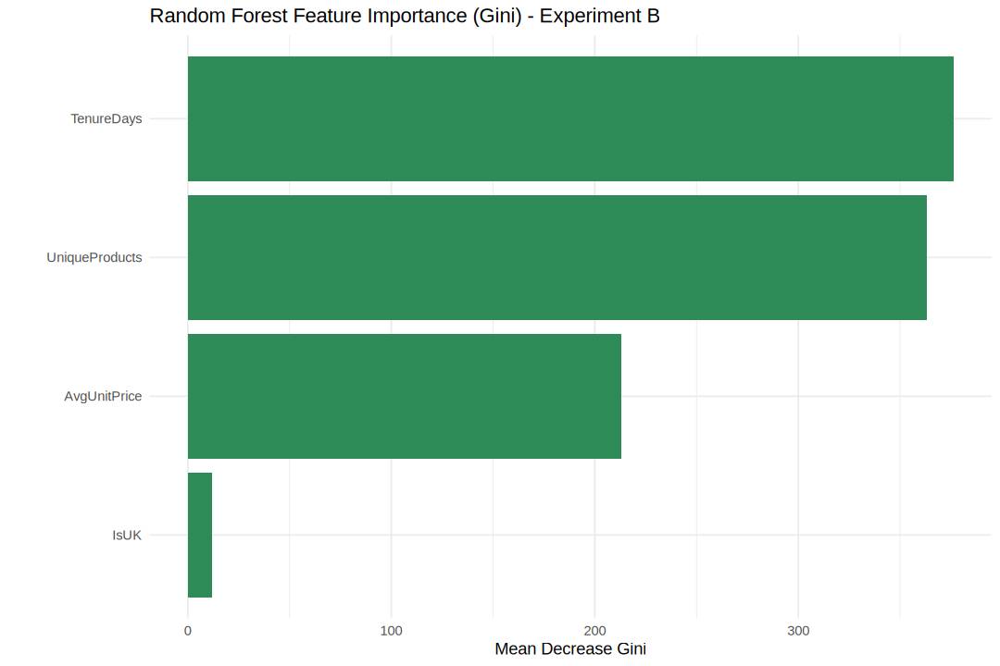

In [45]:
imp_B <- as.data.frame(importance(resB$rf_fit))
imp_B$Feature <- rownames(imp_B)
imp_B <- imp_B[order(imp_B$MeanDecreaseGini, decreasing = TRUE), ]
print(imp_B[, c("Feature", "MeanDecreaseAccuracy", "MeanDecreaseGini")])

ggplot(imp_B, aes(x = reorder(Feature, MeanDecreaseGini), y = MeanDecreaseGini)) +
  geom_col(fill = "seagreen") +
  coord_flip() +
  labs(title = "Random Forest Feature Importance (Gini) - Experiment B", x = "", y = "Mean Decrease Gini") +
  theme_minimal()

## 15. Interactive 3D Visualization of Customer Clusters (Plotly)

Two interactive 3D plots are created: one in PCA space (PC1, PC2, PC3) and one using the log-scaled
Recency, Frequency and Monetary values.

**Note:** Colab's R runtime does not always display Plotly widgets inline. The cell therefore saves each plot as an
HTML file in `/content` and also tries to display it. If nothing appears, open the **Files** panel, download
`clusters_3d_pca.html` and `clusters_3d_rfm.html`, and open them in your browser. Interactive plots do not appear in a PDF export,
so for the PDF submission rely on the static 2D PCA plot above and include a screenshot of the 3D plot if needed.

In [46]:
show_widget <- function(w, file) {
  out <- file.path(data_dir, file)
  saved <- tryCatch({
    saveWidget(w, out, selfcontained = TRUE); TRUE
  }, error = function(e) {
    tryCatch({ saveWidget(w, out, selfcontained = FALSE); TRUE }, error = function(e2) FALSE)
  })
  if (saved) cat("Saved:", out, "\n")
  tryCatch(
    IRdisplay::display_html(paste(readLines(out, warn = FALSE), collapse = "\n")),
    error = function(e) message("Inline display not available. Download the HTML file from the Files panel.")
  )
}

hover_txt <- paste0("CustomerID: ", cust$CustomerID,
                    "<br>Recency: ", round(cust_w$Recency),
                    "<br>Frequency: ", round(cust_w$Frequency),
                    "<br>Monetary: ", round(cust_w$Monetary, 1))

p3d_pca <- plot_ly(pca_df, x = ~PC1, y = ~PC2, z = ~PC3, color = ~Segment,
                   type = "scatter3d", mode = "markers",
                   marker = list(size = 3, opacity = 0.7),
                   text = hover_txt, hoverinfo = "text") %>%
  layout(title = "Customer Clusters in 3D PCA Space",
         scene = list(xaxis = list(title = "PC1"),
                      yaxis = list(title = "PC2"),
                      zaxis = list(title = "PC3")))

show_widget(p3d_pca, "clusters_3d_pca.html")

<!DOCTYPE html>
 
 
 
 plotly

Saved: /content/clusters_3d_pca.html 


In [47]:
rfm_df <- data.frame(Recency = X[, "Recency"], Frequency = X[, "Frequency"],
                     Monetary = X[, "Monetary"], Segment = cust$Segment)

p3d_rfm <- plot_ly(rfm_df, x = ~Recency, y = ~Frequency, z = ~Monetary, color = ~Segment,
                   type = "scatter3d", mode = "markers",
                   marker = list(size = 3, opacity = 0.7),
                   text = hover_txt, hoverinfo = "text") %>%
  layout(title = "Customer Clusters in 3D RFM Space (log-scaled, standardized)",
         scene = list(xaxis = list(title = "Recency (scaled)"),
                      yaxis = list(title = "Frequency (scaled)"),
                      zaxis = list(title = "Monetary (scaled)")))

show_widget(p3d_rfm, "clusters_3d_rfm.html")

<!DOCTYPE html>
 
 
 
 plotly

Saved: /content/clusters_3d_rfm.html 


## 16. Segment-Wise Targeted Marketing Recommendations

The table below attaches a recommended strategy to each segment according to its label. The profile table
from Section 11 should be read together with these recommendations.

In [48]:
strategy_lookup <- c(
  "High-Value Champions" = paste(
    "Create a VIP / loyalty tier with early access to new products and exclusive bundles.",
    "Offer personalised service and referral rewards.",
    "Avoid heavy discounting because these customers already buy at high value.",
    "Monitor recency closely and intervene quickly if purchase gaps appear."),
  "Developing Regulars" = paste(
    "Cross-sell and up-sell using product bundles and recommendations based on past purchases.",
    "Introduce free-shipping or spend-threshold offers to raise average basket value.",
    "Send replenishment reminders and seasonal campaigns to increase purchase frequency.",
    "Invite to the loyalty programme to move them toward the champion segment."),
  "At-Risk / Lapsing" = paste(
    "Run win-back campaigns with time-limited offers and reminder emails.",
    "Use personalised recommendations from their earlier purchases.",
    "Send a short feedback survey to learn why activity has dropped.",
    "Prioritise by past spend so that marketing effort goes to the most valuable lapsing customers."),
  "Dormant / Low-Value" = paste(
    "Use low-cost automated email campaigns only.",
    "Promote clearance items and seasonal sales to trigger occasional purchases.",
    "Test a final reactivation offer, then reduce contact frequency for non-responders.",
    "Do not invest heavy acquisition-style budget in this group.")
)

reco <- ctr[, c("Cluster", "Segment", "Label")]
reco$Customers <- as.integer(table(cust$KMeans)[as.character(reco$Cluster)])
reco$RevenueShare_pct <- round(profile$RevenueShare[match(reco$Segment, profile$Segment)], 1)
reco$Strategy <- strategy_lookup[reco$Label]
reco <- reco[order(-reco$RevenueShare_pct), ]

for (i in seq_len(nrow(reco))) {
  cat("--------------------------------------------------------------\n")
  cat("Segment :", reco$Segment[i], "\n")
  cat("Customers:", reco$Customers[i], " | Revenue share:", reco$RevenueShare_pct[i], "%\n")
  cat("Strategy :", reco$Strategy[i], "\n")
}
cat("--------------------------------------------------------------\n")

--------------------------------------------------------------
Segment : C1: High-Value Champions 
Customers: 734  | Revenue share: 67.1 %
Strategy : Create a VIP / loyalty tier with early access to new products and exclusive bundles. Offer personalised service and referral rewards. Avoid heavy discounting because these customers already buy at high value. Monitor recency closely and intervene quickly if purchase gaps appear. 
--------------------------------------------------------------
Segment : C3: Developing Regulars 
Customers: 1841  | Revenue share: 27.2 %
Strategy : Cross-sell and up-sell using product bundles and recommendations based on past purchases. Introduce free-shipping or spend-threshold offers to raise average basket value. Send replenishment reminders and seasonal campaigns to increase purchase frequency. Invite to the loyalty programme to move them toward the champion segment. 
--------------------------------------------------------------
Segment : C2: Dormant / Lo

## 17. Interpretation of Results and Conclusion
The cell below prints an automatic summary of the key numbers from this run. Use it, together with the plots above,
to write your interpretation in your own words for the final submission.

In [49]:
hv_row <- profile[grepl("High-Value", profile$Segment), ]

cat("SUMMARY OF RESULTS\n")
cat("==================\n")
cat("Customers analysed after cleaning        :", nrow(cust), "\n")
cat("Optimal number of clusters (K_OPT)       :", K_OPT, "\n")
cat("Average silhouette - K-Means             :", round(avg_sil_km, 4), "\n")
cat("Average silhouette - Hierarchical        :", round(avg_sil_hc, 4), "\n")
cat("Adjusted Rand Index (KMeans vs Hier)     :", round(ari, 4), "\n")
cat("PCA: variance explained by PC1 + PC2     :", round(100 * sum(var_exp[1:2]), 1), "%\n")
cat("High-value segment                       :", as.character(hv_row$Segment), "\n")
cat("  Share of customers                     :", hv_row$CustomerShare, "%\n")
cat("  Share of revenue                       :", round(hv_row$RevenueShare, 1), "%\n")
cat("Best predictive model (by ROC-AUC)       :", best_row$Model, "\n")
cat("  Accuracy / Precision / Recall / F1     :", best_row$Accuracy, "/", best_row$Precision, "/",
    best_row$Recall, "/", best_row$F1, "\n")
cat("Most important feature (Experiment A)    :", imp_A$Feature[1], "\n")
cat("Most important feature (Experiment B)    :", imp_B$Feature[1], "\n")

SUMMARY OF RESULTS
Customers analysed after cleaning        : 4334 
Optimal number of clusters (K_OPT)       : 3 
Average silhouette - K-Means             : 0.2823 
Average silhouette - Hierarchical        : 0.2553 
Adjusted Rand Index (KMeans vs Hier)     : 0.4161 
PCA: variance explained by PC1 + PC2     : 74.1 %
High-value segment                       : C1: High-Value Champions 
  Share of customers                     : 16.9 %
  Share of revenue                       : 67.1 %
Best predictive model (by ROC-AUC)       : SVM (RBF) (A: full features) 
  Accuracy / Precision / Recall / F1     : 0.9988 / 1 / 0.9932 / 0.9966 
Most important feature (Experiment A)    : Frequency 
Most important feature (Experiment B)    : TenureDays 


### Points to Discuss in Your Conclusion

1. **Segmentation quality:** Compare the silhouette scores of K-Means and Hierarchical clustering and mention the ARI value. A high ARI means both methods discover a similar structure, which increases confidence in the segments.
2. **Business meaning of segments:** Describe each cluster using the profile table (Recency, Frequency, Monetary, etc.), and note how a small share of customers typically contributes a large share of revenue (see the customer share vs revenue share chart).
3. **PCA view:** State how much variance PC1 and PC2 capture and whether the segments are visibly separated in 2D. Some overlap between neighbouring clusters is normal because customer behaviour is continuous.
4. **Prediction results:** Compare Random Forest and SVM using Accuracy, Precision, Recall, F1 and ROC-AUC. Explain that Experiment A scores are very high because the target is defined from the same features (leakage by design), whereas Experiment B gives a more realistic measure of predictive power.
5. **Feature importance:** Discuss which features drive the prediction (typically Monetary, Frequency and TotalQuantity in Experiment A).
6. **Limitations:** Single retailer, one year of data, customers without ID removed, cluster labels depend on the chosen k and the random seed, and the target is derived from unsupervised clusters rather than a true business definition of value.
7. **Recommendations:** Summarise the segment-wise marketing strategies from Section 16.

